# ML Models with PCA Optimization
## Phase 2: Optimization - Dimensionality Reduction



### Models:
1. Random Forest (RF)
2. Decision Tree (DT)
3. XGBoost ⭐ Best performer
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)
6. Naive Bayes (NB)

## 1️⃣ Import Libraries

In [11]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Configuration

In [12]:
# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "archive/full_df_binary_labels.csv"
BASE_MODEL_DIR = "trained_models/ml_optimized/pca/"
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAVE_MODELS = True

# ========================================
# PCA CONFIGURATION
# ========================================
# Option 1: Set number of components directly
N_COMPONENTS = 30  # Reduce 59 features to 30 principal components

# Option 2: Set variance to retain (uncomment to use)
# N_COMPONENTS = 0.95  # Retain 95% of variance

print(f"🎯 PCA Configuration: {N_COMPONENTS} components")

# ========================================
# PER-MODEL DATASET SIZE CONTROL
# ========================================

MODEL_SAMPLE_SIZES = {
    'Random Forest': None,        # Fast - use full dataset
    'Decision Tree': None,        # Fast - use full dataset
    'XGBoost': None,              # Fast - use full dataset ⭐ BEST MODEL
    'KNN': 50000,                 # SLOW - use only 50k rows
    'SVM': 100000,                # VERY SLOW - use only 100k rows
    'Naive Bayes': None           # Fast - use full dataset
}

print("\n📊 Per-Model Sample Sizes:")
for model, size in MODEL_SAMPLE_SIZES.items():
    size_str = 'Full dataset' if size is None else f'{size:,} rows'
    marker = ' ⭐' if model == 'XGBoost' else ''
    print(f"   {model}: {size_str}{marker}")

# Create base directory
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print(f"\n✅ Base model directory: {BASE_MODEL_DIR}")
print(f"\n🎯 Optimization: PCA (Principal Component Analysis)")

🎯 PCA Configuration: 30 components

📊 Per-Model Sample Sizes:
   Random Forest: Full dataset
   Decision Tree: Full dataset
   XGBoost: Full dataset ⭐
   KNN: 50,000 rows
   SVM: 100,000 rows
   Naive Bayes: Full dataset

✅ Base model directory: trained_models/ml_optimized/pca/

🎯 Optimization: PCA (Principal Component Analysis)


## 3️⃣ Load Dataset

In [13]:
# ========================================
# LOAD DATASET (Memory-Efficient)
# ========================================

CHUNK_SIZE = 100000
MAX_ROWS = None  # None = load all data, or set a limit

chunks = []
total_rows = 0

print("⏳ Reading data...")
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    
    chunks.append(chunk)
    total_rows += len(chunk)
    
    if (i + 1) % 5 == 0:
        print(f"   Loaded chunk {i+1}: {total_rows:,} rows total")

print(f"\n✅ Loaded {len(chunks)} chunks")
print(f"✅ Total rows: {total_rows:,}")

print("\n🔗 Combining chunks...")
df_full = pd.concat(chunks, ignore_index=True)
del chunks

print(f"✅ Dataset shape: {df_full.shape}")
print(f"✅ Columns: {len(df_full.columns)}")

⏳ Reading data...
   Loaded chunk 5: 500,000 rows total
   Loaded chunk 10: 1,000,000 rows total
   Loaded chunk 15: 1,500,000 rows total
   Loaded chunk 20: 2,000,000 rows total
   Loaded chunk 25: 2,500,000 rows total
   Loaded chunk 30: 3,000,000 rows total
   Loaded chunk 35: 3,500,000 rows total
   Loaded chunk 40: 4,000,000 rows total
   Loaded chunk 45: 4,500,000 rows total
   Loaded chunk 50: 5,000,000 rows total
   Loaded chunk 55: 5,500,000 rows total
   Loaded chunk 60: 6,000,000 rows total
   Loaded chunk 65: 6,500,000 rows total
   Loaded chunk 70: 7,000,000 rows total
   Loaded chunk 75: 7,500,000 rows total
   Loaded chunk 80: 8,000,000 rows total
   Loaded chunk 85: 8,500,000 rows total
   Loaded chunk 90: 9,000,000 rows total
   Loaded chunk 95: 9,500,000 rows total
   Loaded chunk 100: 10,000,000 rows total
   Loaded chunk 105: 10,500,000 rows total
   Loaded chunk 110: 11,000,000 rows total
   Loaded chunk 115: 11,500,000 rows total
   Loaded chunk 120: 12,000,000 ro

## 4️⃣ Prepare Features and Target

In [14]:
# ========================================
# SEPARATE FEATURES AND TARGET
# ========================================

label_columns = ['Label', 'Label_Binary']
existing_labels = [col for col in label_columns if col in df_full.columns]

X_full = df_full.drop(columns=existing_labels)
y_full = df_full['Label_Binary']

print(f"✅ Features (X): {X_full.shape}")
print(f"✅ Target (y): {y_full.shape}")
print(f"\n📊 Original features: {X_full.shape[1]}")
print(f"📊 After PCA: {N_COMPONENTS} components (reduction: {X_full.shape[1] - N_COMPONENTS} features)")

✅ Features (X): (16232943, 57)
✅ Target (y): (16232943,)

📊 Original features: 57
📊 After PCA: 30 components (reduction: 27 features)


## 5️⃣ Define Models

In [15]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=1),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbosity=1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM': SVC(kernel='rbf', random_state=RANDOM_STATE, verbose=True),
    'Naive Bayes': GaussianNB()
}

print(f"✅ Defined {len(models)} models")

✅ Defined 6 models


## 6️⃣ Helper Functions

In [16]:
def calculate_far(y_true, y_pred):
    """Calculate False Alert Rate: FAR = FP / (FP + TN)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    return far

def get_model_data(X_full, y_full, model_name, sample_size, test_size, random_state):
    """Get train/test split with optional sampling"""
    if sample_size is None:
        X = X_full
        y = y_full
        print(f"📊 Using FULL dataset: {len(X):,} rows")
    else:
        if sample_size > len(X_full):
            print(f"⚠️  Requested {sample_size:,} rows but only {len(X_full):,} available")
            X = X_full
            y = y_full
        else:
            print(f"📊 Sampling {sample_size:,} rows from {len(X_full):,} total (stratified)")
            X, _, y, _ = train_test_split(
                X_full, y_full, 
                train_size=sample_size,
                random_state=random_state,
                stratify=y_full
            )
    
    print(f"🔪 Splitting into train/test ({test_size*100}% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    print(f"✅ Train set: {X_train.shape[0]:,} samples")
    print(f"✅ Test set: {X_test.shape[0]:,} samples")
    
    return X_train, X_test, y_train, y_test

## 7️⃣ Train and Evaluate Models with PCA

In [17]:
# ========================================
# TRAIN AND TEST ALL MODELS WITH PCA
# ========================================

results = {}
trained_models = {}
scalers = {}
pca_transformers = {}

for model_name, model in models.items():
    print("\n" + "="*80)
    print(f"🚀 TRAINING: {model_name} WITH PCA")
    print("="*80)
    
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower().replace(' ', '_'), '')
    os.makedirs(model_dir, exist_ok=True)
    print(f"📁 Model directory: {model_dir}")
    
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
    
    X_train, X_test, y_train, y_test = get_model_data(
        X_full, y_full, 
        model_name, 
        sample_size, 
        TEST_SIZE, 
        RANDOM_STATE
    )
    
    # ========================================
    # 🎯 STEP 1: STANDARDIZE (Required for PCA)
    # ========================================
    print(f"\n⚖️  Step 1/2: Standardizing features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print(f"✅ Features standardized: mean=0, std=1")
    
    # ========================================
    # 🎯 STEP 2: APPLY PCA
    # ========================================
    print(f"\n🔬 Step 2/2: Applying PCA...")
    print(f"   Original dimensions: {X_train_scaled.shape[1]}")
    
    pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    print(f"   Reduced dimensions: {X_train_pca.shape[1]}")
    print(f"   Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
    print(f"   Reduction: {X_train_scaled.shape[1] - X_train_pca.shape[1]} features removed")
    print(f"✅ PCA transformation complete")
    
    # Save transformers
    scalers[model_name] = scaler
    pca_transformers[model_name] = pca
    
    if SAVE_MODELS:
        with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
            pickle.dump(scaler, f)
        with open(os.path.join(model_dir, 'pca.pkl'), 'wb') as f:
            pickle.dump(pca, f)
        print(f"💾 Scaler & PCA saved")
    
    # Training
    print(f"\n⏱️  Training with PCA-reduced features...")
    start_time = time.time()
    model.fit(X_train_pca, y_train)
    train_time = time.time() - start_time
    print(f"✅ Training completed in {train_time:.2f} seconds ({train_time/60:.2f} minutes)")
    
    # Prediction
    print(f"\n🔮 Making predictions...")
    start_time = time.time()
    y_pred = model.predict(X_test_pca)
    pred_time = time.time() - start_time
    print(f"✅ Predictions completed in {pred_time:.2f} seconds")
    
    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    cm = confusion_matrix(y_test, y_pred)
    far = calculate_far(y_test, y_pred)
    
    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'far': far,
        'train_time': train_time,
        'pred_time': pred_time,
        'confusion_matrix': cm,
        'predictions': y_pred,
        'sample_size': len(X_train) + len(X_test),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'optimization': 'PCA',
        'n_components': N_COMPONENTS,
        'variance_explained': pca.explained_variance_ratio_.sum()
    }
    
    trained_models[model_name] = model
    
    # Print metrics
    print(f"\n📊 RESULTS WITH PCA:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   FAR:       {far:.4f} ({far*100:.2f}%)  ⭐ Key Metric!")
    
    if model_name == 'XGBoost':
        print(f"\n🏆 EXPECTED: ~99.97% accuracy, 0% FAR (Best in paper!)")
        if accuracy > 0.999:
            print(f"✅ ACHIEVED! Accuracy: {accuracy*100:.2f}%")
    
    print(f"\n🕐 TIME:")
    print(f"   Train: {train_time:.2f}s ({train_time/60:.2f} min)")
    print(f"   Test:  {pred_time:.2f}s")
    
    print(f"\n🎯 Confusion Matrix:")
    print(cm)
    
    # Save model
    if SAVE_MODELS:
        with open(os.path.join(model_dir, 'model.pkl'), 'wb') as f:
            pickle.dump(model, f)
        
        metadata = {
            'model_name': model_name,
            'optimization': 'PCA',
            'n_components': N_COMPONENTS,
            'variance_explained': pca.explained_variance_ratio_.sum(),
            'sample_size': sample_size,
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'original_features': X_train.shape[1],
            'pca_features': X_train_pca.shape[1],
            'train_time': train_time,
            'metrics': {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'far': far
            }
        }
        
        with open(os.path.join(model_dir, 'metadata.pkl'), 'wb') as f:
            pickle.dump(metadata, f)
        print(f"\n💾 Model & metadata saved")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED & TESTED WITH PCA!")
print("="*80)


🚀 TRAINING: Random Forest WITH PCA
📁 Model directory: trained_models/ml_optimized/pca/random_forest\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20.0% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples

⚖️  Step 1/2: Standardizing features...
✅ Features standardized: mean=0, std=1

🔬 Step 2/2: Applying PCA...
   Original dimensions: 57
   Reduced dimensions: 30
   Variance explained: 99.77%
   Reduction: 27 features removed
✅ PCA transformation complete
💾 Scaler & PCA saved

⏱️  Training with PCA-reduced features...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed: 10.1min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 34.2min finished


✅ Training completed in 2060.89 seconds (34.35 minutes)

🔮 Making predictions...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:   14.1s finished


✅ Predictions completed in 16.03 seconds

📊 RESULTS WITH PCA:
   Accuracy:  0.9878 (98.78%)
   Precision: 0.9807
   Recall:    0.9464
   F1-Score:  0.9633
   FAR:       0.0038 (0.38%)  ⭐ Key Metric!

🕐 TIME:
   Train: 2060.89s (34.35 min)
   Test:  16.03s

🎯 Confusion Matrix:
[[2686714   10228]
 [  29450  520197]]

💾 Model & metadata saved

🚀 TRAINING: Decision Tree WITH PCA
📁 Model directory: trained_models/ml_optimized/pca/decision_tree\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20.0% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples

⚖️  Step 1/2: Standardizing features...
✅ Features standardized: mean=0, std=1

🔬 Step 2/2: Applying PCA...
   Original dimensions: 57
   Reduced dimensions: 30
   Variance explained: 99.77%
   Reduction: 27 features removed
✅ PCA transformation complete
💾 Scaler & PCA saved

⏱️  Training with PCA-reduced features...
✅ Training completed in 1540.52 seconds (25.68 minutes)

🔮 Making predictions...
✅ Predictio

## 8️⃣ Results Summary

In [18]:
print("\n" + "="*100)
print("📊 FINAL RESULTS SUMMARY - PCA Optimization")
print("="*100)

results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'FAR': [results[m]['far'] for m in results.keys()],
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()],
    'Variance Explained': [results[m]['variance_explained'] for m in results.keys()],
    'Samples': [results[m]['sample_size'] for m in results.keys()]
})

results_df = results_df.sort_values('Accuracy', ascending=False)
results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(4)
results_df['FAR %'] = (results_df['FAR'] * 100).round(4)
results_df['Variance %'] = (results_df['Variance Explained'] * 100).round(2)

print("\n")
display(results_df)

print("\n🏆 BEST PERFORMERS:")
print(f"   Highest Accuracy: {results_df.iloc[0]['Model']} - {results_df.iloc[0]['Accuracy %']:.4f}%")
print(f"   Lowest FAR: {results_df.loc[results_df['FAR'].idxmin()]['Model']} - {results_df['FAR'].min()*100:.4f}%")

if results_df.iloc[0]['Model'] == 'XGBoost' and results_df.iloc[0]['Accuracy'] > 0.9997:
    print(f"\n🎉 SUCCESS! XGBoost achieved paper's best result: {results_df.iloc[0]['Accuracy %']:.4f}%")

results_path = os.path.join(BASE_MODEL_DIR, 'results_summary.csv')
results_df.to_csv(results_path, index=False)
print(f"\n💾 Results saved: {results_path}")


📊 FINAL RESULTS SUMMARY - PCA Optimization




,Model,Accuracy,Precision,Recall,F1-Score,FAR,Train Time (s),Variance Explained,Samples,Accuracy %,FAR %,Variance %
2,XGBoost,0.989998,0.998362,0.942467,0.969609,0.000315,34.697859,0.997741,16232943,98.9998,0.0315,99.77
3,KNN,0.988700,0.987654,0.945068,0.965892,0.002408,0.004027,0.998449,50000,98.8700,0.2408,99.84
0,Random Forest,0.987779,0.980717,0.946420,0.963264,0.003792,2060.889192,0.997741,16232943,98.7779,0.3792,99.77
1,Decision Tree,0.985061,0.963852,0.947286,0.955497,0.007240,1540.516576,0.997741,16232943,98.5061,0.7240,99.77
4,SVM,0.977700,0.993620,0.873892,0.929918,0.001144,16.135478,0.998248,100000,97.7700,0.1144,99.82
5,Naive Bayes,0.385632,0.213707,0.981177,0.350970,0.735742,10.709986,0.997741,16232943,38.5632,73.5742,99.77



🏆 BEST PERFORMERS:
   Highest Accuracy: XGBoost - 98.9998%
   Lowest FAR: XGBoost - 0.0315%

💾 Results saved: trained_models/ml_optimized/pca/results_summary.csv


## 9️⃣ Visualization

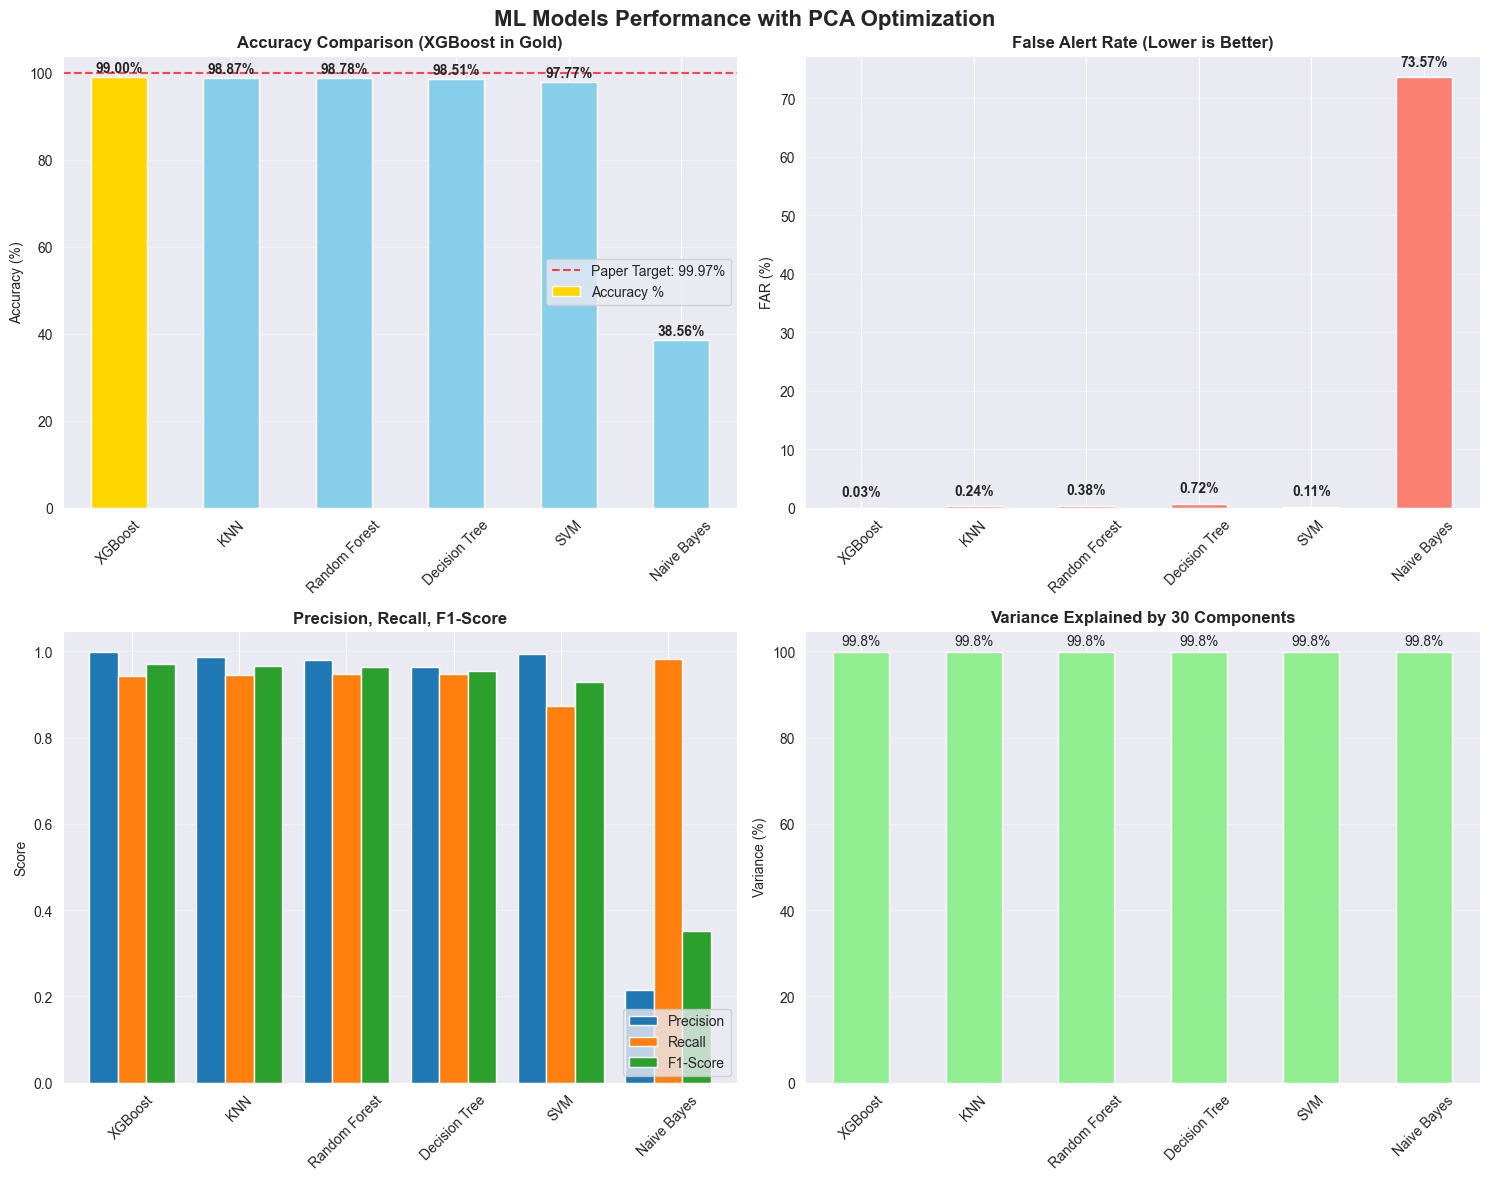


💾 Chart saved: performance_comparison_pca.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('ML Models Performance with PCA Optimization', fontsize=16, fontweight='bold')

# 1. Accuracy Comparison
ax1 = axes[0, 0]
colors = ['gold' if m == 'XGBoost' else 'skyblue' for m in results_df['Model']]
results_df.plot(x='Model', y='Accuracy %', kind='bar', ax=ax1, color=colors, legend=False)
ax1.set_title('Accuracy Comparison (XGBoost in Gold)', fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=99.97, color='r', linestyle='--', label='Paper Target: 99.97%', alpha=0.7)
ax1.legend()

for i, v in enumerate(results_df['Accuracy %']):
    ax1.text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# 2. FAR Comparison
ax2 = axes[0, 1]
results_df.plot(x='Model', y='FAR %', kind='bar', ax=ax2, color='salmon', legend=False)
ax2.set_title('False Alert Rate (Lower is Better)', fontweight='bold')
ax2.set_ylabel('FAR (%)')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

for i, v in enumerate(results_df['FAR %']):
    ax2.text(i, v + max(results_df['FAR %'])*0.02, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# 3. Precision, Recall, F1
ax3 = axes[1, 0]
metrics_to_plot = results_df[['Model', 'Precision', 'Recall', 'F1-Score']].set_index('Model')
metrics_to_plot.plot(kind='bar', ax=ax3, width=0.8)
ax3.set_title('Precision, Recall, F1-Score', fontweight='bold')
ax3.set_ylabel('Score')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(loc='lower right')
ax3.grid(axis='y', alpha=0.3)

# 4. Variance Explained
ax4 = axes[1, 1]
results_df.plot(x='Model', y='Variance %', kind='bar', ax=ax4, color='lightgreen', legend=False)
ax4.set_title(f'Variance Explained by {N_COMPONENTS} Components', fontweight='bold')
ax4.set_ylabel('Variance (%)')
ax4.set_xlabel('')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

for i, v in enumerate(results_df['Variance %']):
    ax4.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(BASE_MODEL_DIR, 'performance_comparison_pca.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Chart saved: performance_comparison_pca.png")

## 🔟 PCA Analysis

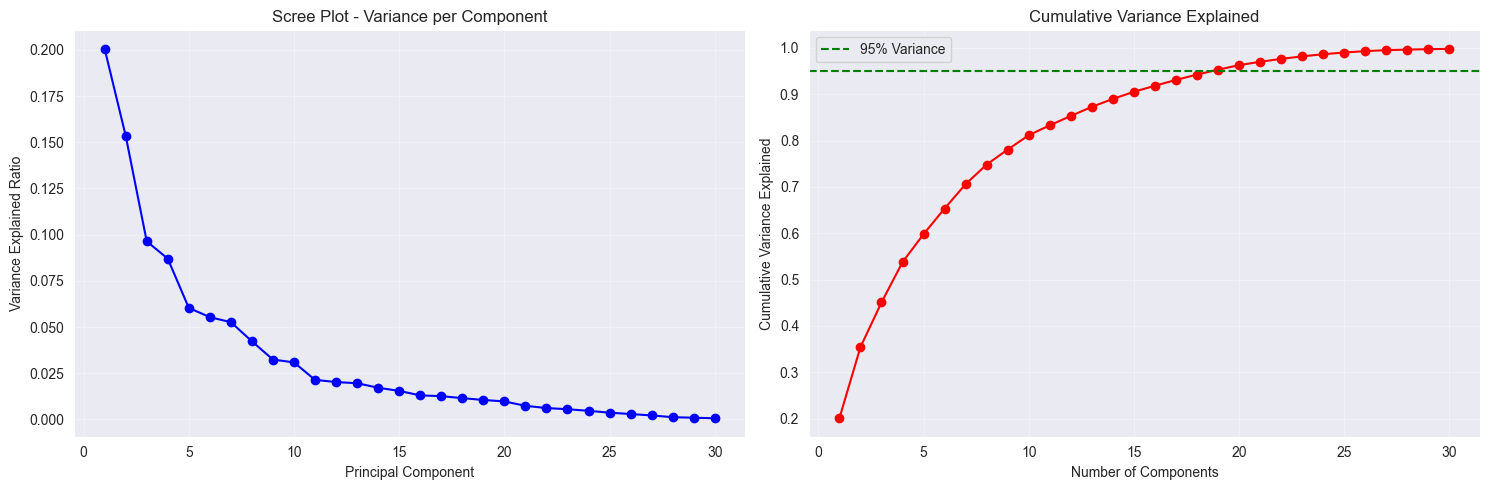


📊 PCA Analysis:
   Components: 30
   Total variance explained: 99.77%
   Top 5 components explain: 59.79%
   Top 10 components explain: 81.14%


In [20]:
# Analyze PCA components (using XGBoost's PCA as example)
if 'XGBoost' in pca_transformers:
    pca = pca_transformers['XGBoost']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 1. Scree plot - variance per component
    ax1 = axes[0]
    ax1.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
             pca.explained_variance_ratio_, 'bo-')
    ax1.set_xlabel('Principal Component')
    ax1.set_ylabel('Variance Explained Ratio')
    ax1.set_title('Scree Plot - Variance per Component')
    ax1.grid(True, alpha=0.3)
    
    # 2. Cumulative variance
    ax2 = axes[1]
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    ax2.plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
    ax2.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('Cumulative Variance Explained')
    ax2.set_title('Cumulative Variance Explained')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_MODEL_DIR, 'pca_analysis.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 PCA Analysis:")
    print(f"   Components: {len(pca.explained_variance_ratio_)}")
    print(f"   Total variance explained: {cumsum[-1]*100:.2f}%")
    print(f"   Top 5 components explain: {cumsum[4]*100:.2f}%")
    print(f"   Top 10 components explain: {cumsum[9]*100:.2f}%")